Starting Capital : ₹1,00,000
Final Value      : ₹125,694
Profit/Loss      : ₹25,694
Return           : 25.69%

Trades:
  2026-04-28 | BUY | ₹2411 | 41 shares


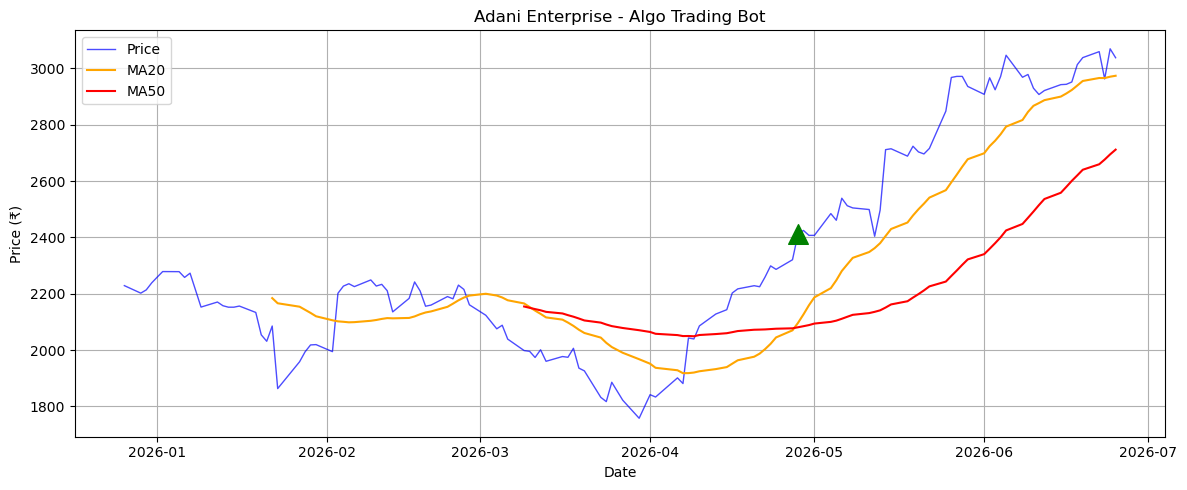

In [1]:
# ================================================
# ALGO TRADING BOT - NSE Stocks
# Strategy: MA Crossover + RSI
# Author: Amogh Kulkarni
# ================================================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. FETCH DATA ────────────────────────────────
ticker = "ADANIENT.NS"
stock = yf.download(ticker, period="6mo", interval="1d", progress=False)
stock['MA20'] = stock['Close'].rolling(20).mean()
stock['MA50'] = stock['Close'].rolling(50).mean()

# ── 2. RSI CALCULATION ───────────────────────────
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    rs = gain.rolling(window).mean() / loss.rolling(window).mean()
    return 100 - (100 / (1 + rs))

stock['RSI'] = calculate_rsi(stock['Close'])

# ── 3. BUY/SELL SIGNALS ──────────────────────────
capital = 100000
shares = 0
trades = []

for i in range(1, len(stock)):
    ma20 = stock['MA20'].iloc[i].item()
    ma50 = stock['MA50'].iloc[i].item()
    prev_ma20 = stock['MA20'].iloc[i-1].item()
    prev_ma50 = stock['MA50'].iloc[i-1].item()
    close = stock['Close'].iloc[i].item()

    if prev_ma20 <= prev_ma50 and ma20 > ma50:
        shares = capital // close
        capital -= shares * close
        trades.append({'Date': stock.index[i], 'Action': 'BUY', 'Price': close, 'Shares': shares})

    elif prev_ma20 >= prev_ma50 and ma20 < ma50:
        if shares > 0:
            capital += shares * close
            trades.append({'Date': stock.index[i], 'Action': 'SELL', 'Price': close, 'Shares': shares})
            shares = 0

# ── 4. RESULTS ───────────────────────────────────
final_value = capital + (shares * stock['Close'].iloc[-1].item())
print(f"Starting Capital : ₹1,00,000")
print(f"Final Value      : ₹{final_value:,.0f}")
print(f"Profit/Loss      : ₹{final_value - 100000:,.0f}")
print(f"Return           : {((final_value - 100000)/100000)*100:.2f}%")
print(f"\nTrades:")
for t in trades:
    print(f"  {t['Date'].date()} | {t['Action']} | ₹{t['Price']:.0f} | {t['Shares']:.0f} shares")

# ── 5. CHART ─────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(stock['Close'], label='Price', color='blue', linewidth=1, alpha=0.7)
plt.plot(stock['MA20'], label='MA20', color='orange', linewidth=1.5)
plt.plot(stock['MA50'], label='MA50', color='red', linewidth=1.5)

for t in trades:
    color = 'green' if t['Action'] == 'BUY' else 'red'
    marker = '^' if t['Action'] == 'BUY' else 'v'
    plt.scatter(t['Date'], t['Price'], color=color, marker=marker, s=200, zorder=5)

plt.title('Adani Enterprise - Algo Trading Bot')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()